In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload retail_sales_dataset.csv

Saving archive (4).zip to archive (4) (2).zip
Saving archive (3).zip to archive (3) (2).zip


No zip file found in 'uploaded' dictionary. Please upload 'retail_sales_dataset.csv' directly or a zip containing it.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('menu.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (260, 24)

First 5 rows:
    Category                              Item    Serving Size  Calories  \
0  Breakfast                      Egg McMuffin  4.8 oz (136 g)       300   
1  Breakfast                 Egg White Delight  4.8 oz (135 g)       250   
2  Breakfast                  Sausage McMuffin  3.9 oz (111 g)       370   
3  Breakfast         Sausage McMuffin with Egg  5.7 oz (161 g)       450   
4  Breakfast  Sausage McMuffin with Egg Whites  5.7 oz (161 g)       400   

   Calories from Fat  Total Fat  Total Fat (% Daily Value)  Saturated Fat  \
0                120       13.0                         20            5.0   
1                 70        8.0                         12            3.0   
2                200       23.0                         35            8.0   
3                250       28.0                         43           10.0   
4                210       23.0                         35            8.0   

   Saturated Fat (% Daily Value)  Trans Fat  ...

In [ ]:
import pandas as pd

# Ensure df is defined. This addresses the NameError if the previous cell wasn't run.
# However, it's typically better to ensure previous cells run in order.
# Assuming menu.csv is the intended file based on prior successful load.
if 'df' not in locals() and 'df' not in globals():
    try:
        df = pd.read_csv('menu.csv')
        print("DataFrame 'df' was not found; re-loaded from 'menu.csv'.")
    except FileNotFoundError:
        print("Error: 'menu.csv' not found. Please ensure the file is uploaded and extracted.")
        raise # Re-raise to stop execution if file is truly missing

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()

# The original code here tried to convert 'Date' column and extract month/year.
# However, the loaded 'menu.csv' does not contain a 'Date' column.
# Therefore, these operations are not applicable to the current dataset.
# Removing these lines to prevent KeyError.
# df['Date'] = pd.to_datetime(df['Date'])
# df['Month'] = df['Date'].dt.month
# df['Year'] = df['Date'].dt.year
# df['Month_Name'] = df['Date'].dt.strftime('%B')

print("✅ Data cleaning (duplicates removed) completed based on available columns in 'menu.csv'.")
print(df.head())

Duplicate rows: 0
✅ Data cleaning (duplicates removed) completed based on available columns in 'menu.csv'.
    Category                              Item    Serving Size  Calories  \
0  Breakfast                      Egg McMuffin  4.8 oz (136 g)       300   
1  Breakfast                 Egg White Delight  4.8 oz (135 g)       250   
2  Breakfast                  Sausage McMuffin  3.9 oz (111 g)       370   
3  Breakfast         Sausage McMuffin with Egg  5.7 oz (161 g)       450   
4  Breakfast  Sausage McMuffin with Egg Whites  5.7 oz (161 g)       400   

   Calories from Fat  Total Fat  Total Fat (% Daily Value)  Saturated Fat  \
0                120       13.0                         20            5.0   
1                 70        8.0                         12            3.0   
2                200       23.0                         35            8.0   
3                250       28.0                         43           10.0   
4                210       23.0                    

In [ ]:
print("=== Basic Statistics ===")
# The original code expected 'Total Amount' and 'Product Category'.
# Adapting to 'Calories' and 'Category' from menu.csv.
print(df.describe())

print("\n=== Mean of Calories ===")
print(round(df['Calories'].mean(), 2))

print("\n=== Median of Calories ===")
print(round(df['Calories'].median(), 2))

print("\n=== Mode of Category ===")
# Using 'Category' as it's the most appropriate categorical column
print(df['Category'].mode()[0])

print("\n=== Standard Deviation of Calories ===")
print(round(df['Calories'].std(), 2))

print("\n=== Total Calories (sum) ===")
# Summing calories as a relevant aggregate for this dataset
print(round(df['Calories'].sum(), 2))

=== Basic Statistics ===
          Calories  Calories from Fat   Total Fat  Total Fat (% Daily Value)  \
count   260.000000         260.000000  260.000000                 260.000000   
mean    368.269231         127.096154   14.165385                  21.815385   
std     240.269886         127.875914   14.205998                  21.885199   
min       0.000000           0.000000    0.000000                   0.000000   
25%     210.000000          20.000000    2.375000                   3.750000   
50%     340.000000         100.000000   11.000000                  17.000000   
75%     500.000000         200.000000   22.250000                  35.000000   
max    1880.000000        1060.000000  118.000000                 182.000000   

       Saturated Fat  Saturated Fat (% Daily Value)   Trans Fat  Cholesterol  \
count     260.000000                     260.000000  260.000000   260.000000   
mean        6.007692                      29.965385    0.203846    54.942308   
std         5.

In [ ]:
# Calories by Category
print("=== Calories by Category ===")
# Adapting to 'Calories' and 'Category' from menu.csv
print(df.groupby('Category')['Calories'].sum())

# The following sections were for a different dataset and are not applicable here:
# # Sales by gender
# print("\n=== Sales by Gender ===")
# print(df.groupby('Gender')['Total Amount'].sum())

# # Sales by age group
# df['Age Group'] = pd.cut(df['Age'],
#                           bins=[0, 25, 35, 45, 55, 100],
#                           labels=['Under 25', '25-35', '35-45', '45-55', '55+'])
# print("\n=== Sales by Age Group ===")
# print(df.groupby('Age Group')['Total Amount'].sum())

# # Top 5 customers
# print("\n=== Top 5 Customers by Spending ===")
# print(df.groupby('Customer ID')['Total Amount'].sum().nlargest(5))

=== Calories by Category ===
Category
Beef & Pork            7410
Beverages              3070
Breakfast             22120
Chicken & Fish        14930
Coffee & Tea          26970
Desserts               1555
Salads                 1620
Smoothies & Shakes    14880
Snacks & Sides         3195
Name: Calories, dtype: int64


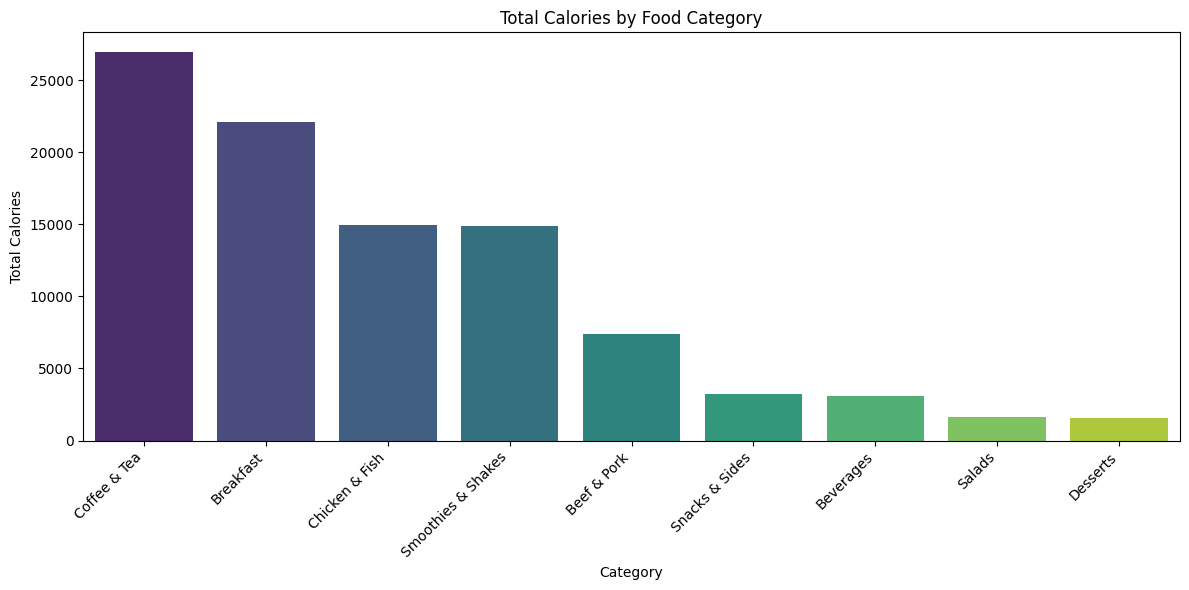

In [ ]:
# Visualization: Total Calories by Category
plt.figure(figsize=(12, 6))
calories_by_category = df.groupby('Category')['Calories'].sum().sort_values(ascending=False)
sns.barplot(x=calories_by_category.index, y=calories_by_category.values, palette='viridis')
plt.title('Total Calories by Food Category')
plt.xlabel('Category')
plt.ylabel('Total Calories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

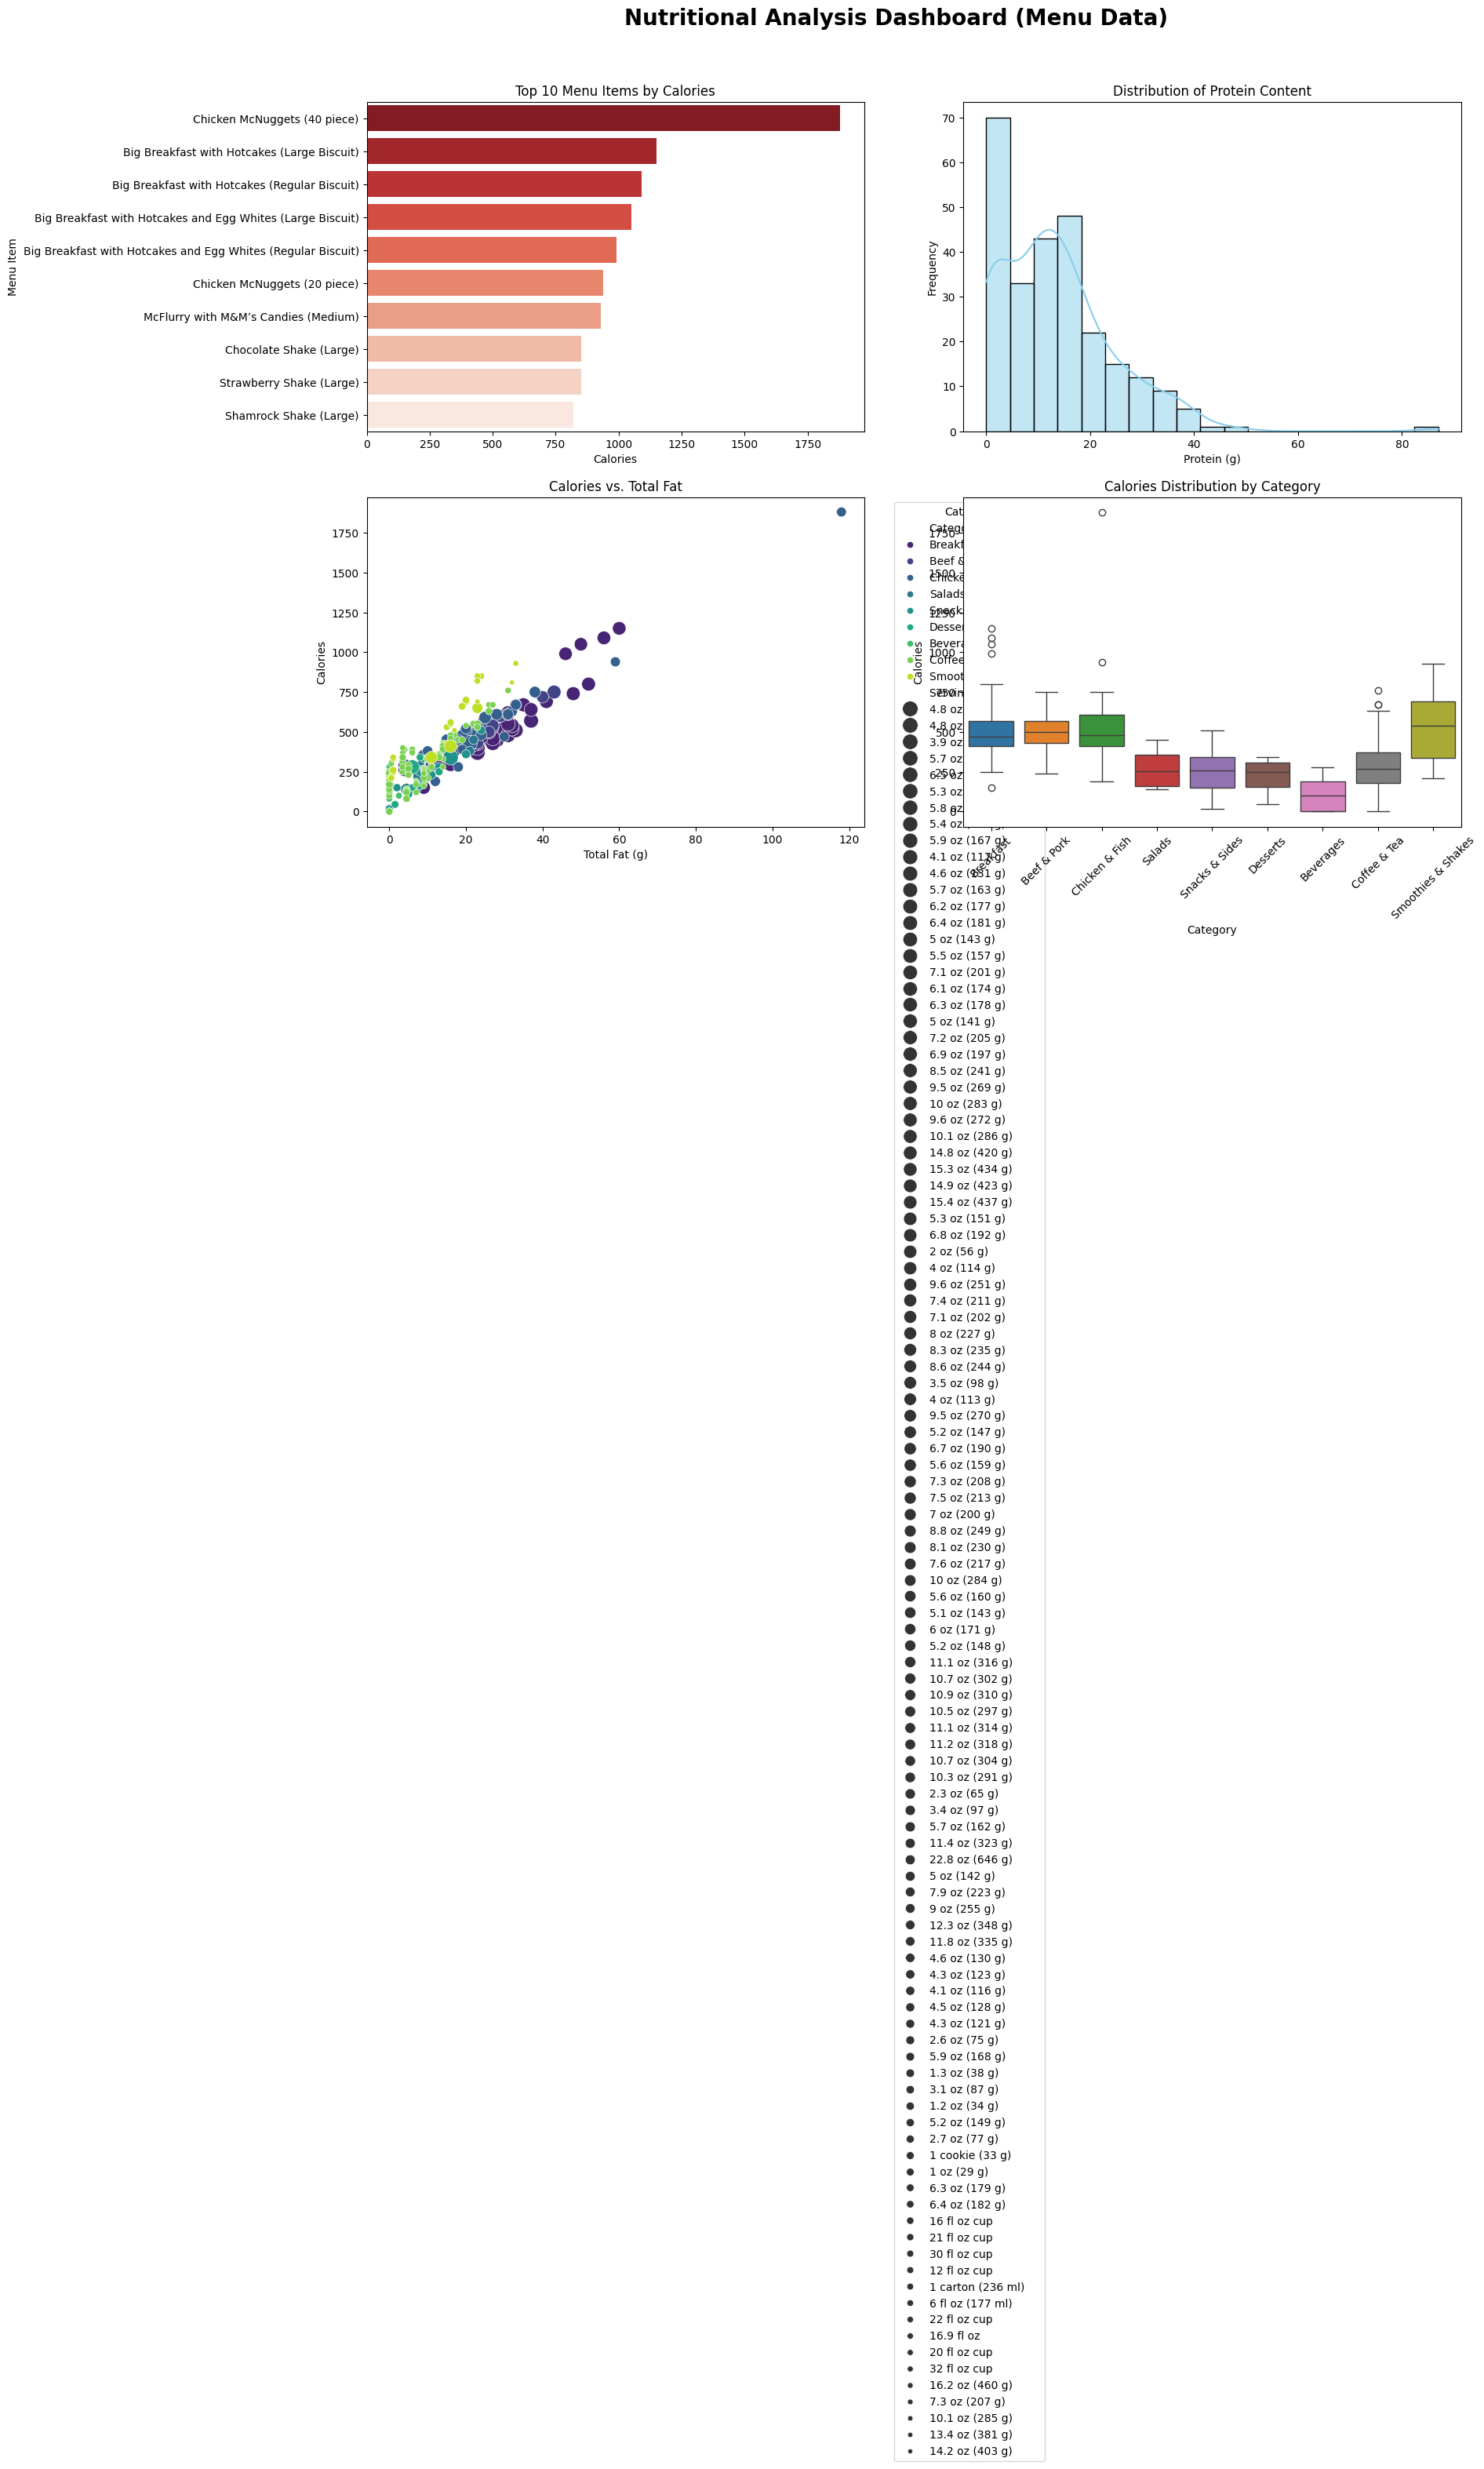

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Nutritional Analysis Dashboard (Menu Data)', fontsize=20, fontweight='bold')

# Chart 1 - Top 10 Items by Calories
top_calorie_items = df[['Item', 'Calories']].sort_values(by='Calories', ascending=False).head(10)
sns.barplot(x='Calories', y='Item', data=top_calorie_items, ax=axes[0,0], palette='Reds_r')
axes[0,0].set_title('Top 10 Menu Items by Calories')
axes[0,0].set_xlabel('Calories')
axes[0,0].set_ylabel('Menu Item')

# Chart 2 - Distribution of Protein
sns.histplot(df['Protein'], kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Distribution of Protein Content')
axes[0,1].set_xlabel('Protein (g)')
axes[0,1].set_ylabel('Frequency')

# Chart 3 - Calories vs. Total Fat (Scatter Plot)
sns.scatterplot(x='Total Fat', y='Calories', data=df, ax=axes[1,0], hue='Category', palette='viridis', size='Serving Size', sizes=(20, 200))
axes[1,0].set_title('Calories vs. Total Fat')
axes[1,0].set_xlabel('Total Fat (g)')
axes[1,0].set_ylabel('Calories')
axes[1,0].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Chart 4 - Box Plot of Calories by Category
sns.boxplot(x='Category', y='Calories', data=df, ax=axes[1,1], palette='tab10')
axes[1,1].set_title('Calories Distribution by Category')
axes[1,1].set_xlabel('Category')
axes[1,1].set_ylabel('Calories')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

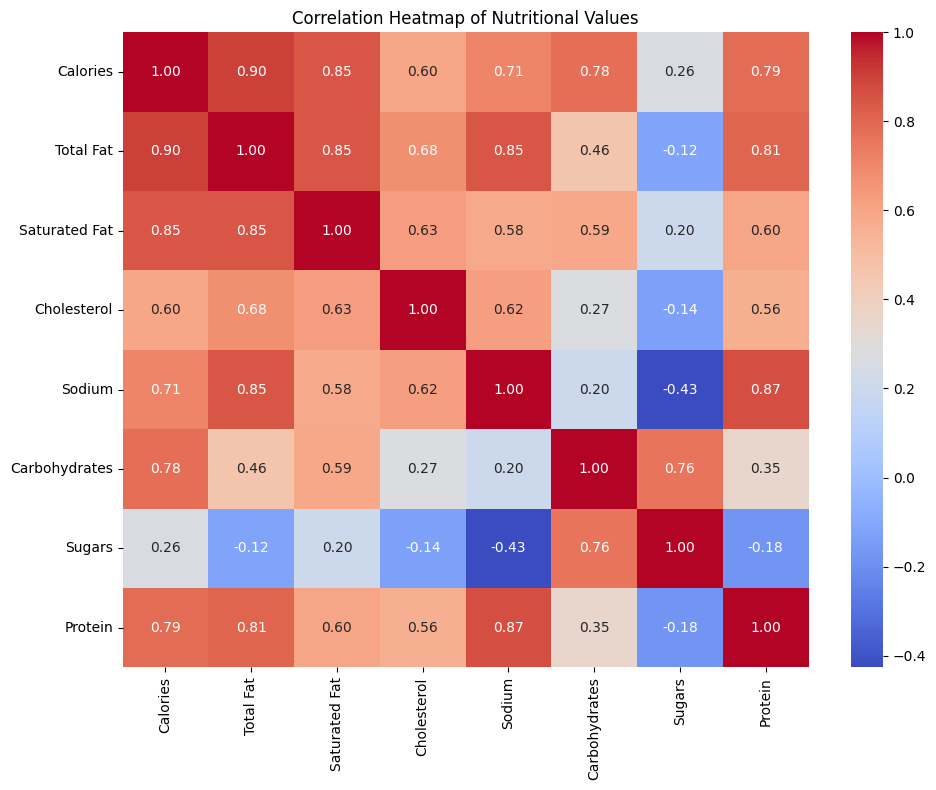

In [ ]:
plt.figure(figsize=(10, 8))
# Select relevant numerical columns from the menu.csv dataset for correlation
numeric_cols = df[['Calories', 'Total Fat', 'Saturated Fat', 'Cholesterol', 'Sodium', 'Carbohydrates', 'Sugars', 'Protein']]
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap of Nutritional Values')
plt.tight_layout()
plt.show()

In [ ]:
print("=== NUTRITIONAL INSIGHTS & RECOMMENDATIONS ===")
print()

# Top category by total calories
top_calorie_category = df.groupby('Category')['Calories'].sum().idxmax()
# Item with highest calories
highest_calorie_item = df.loc[df['Calories'].idxmax()]['Item']
# Item with lowest calories
lowest_calorie_item = df.loc[df['Calories'].idxmin()]['Item']

print(f"1. The category with the highest total calories is: '{top_calorie_category}'.")
print(f"2. The single menu item with the highest calories is: '{highest_calorie_item}'.")
print(f"3. The single menu item with the lowest calories is: '{lowest_calorie_item}'.")
print(f"4. Consider offering more options in categories with lower average calories or promoting lower-calorie alternatives within high-calorie categories.")
print(f"5. Customers looking for healthier options might appreciate clear labeling or suggestions for items with lower fat, sugar, and sodium content.")
print()
print("These insights can help in menu planning and promoting healthier choices! ✅")

=== NUTRITIONAL INSIGHTS & RECOMMENDATIONS ===

1. The category with the highest total calories is: 'Coffee & Tea'.
2. The single menu item with the highest calories is: 'Chicken McNuggets (40 piece)'.
3. The single menu item with the lowest calories is: 'Diet Coke (Small)'.
4. Consider offering more options in categories with lower average calories or promoting lower-calorie alternatives within high-calorie categories.
5. Customers looking for healthier options might appreciate clear labeling or suggestions for items with lower fat, sugar, and sodium content.

These insights can help in menu planning and promoting healthier choices! ✅
